In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures

In [4]:
def setup_plot(plt):
    plt.rcParams.update({
        'font.size': 10,
        'axes.labelweight': 'bold',
        'axes.edgecolor': '#333333',
    })
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_xlabel('x_1', labelpad=10)
    ax.set_ylabel('x_2', labelpad=10)
    ax.set_zlabel('y', labelpad=10)
    ax.view_init(elev=20, azim=-65)
    return ax, fig

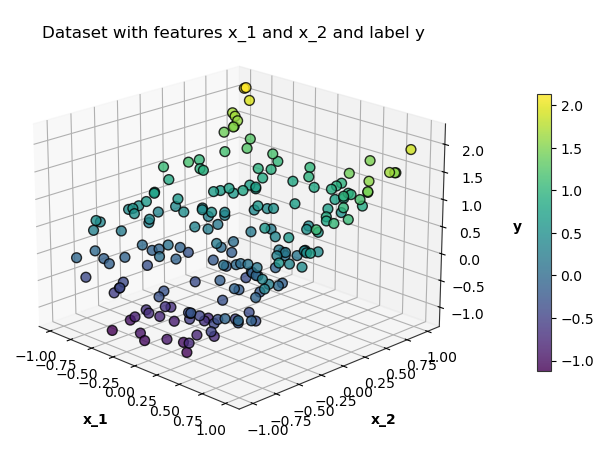

In [5]:
df = pd.read_csv('week3_data.csv', skiprows=1, names=['x1', 'x2', 'y'])

ax, fig = setup_plot(plt)
sc = ax.scatter(
    df['x1'],
    df['x2'],
    df['y'],  # type: ignore
    c=df['y'].values,
    cmap='viridis',
    s=50,
    alpha=0.8,
    edgecolors='k',
    depthshade=True
)

ax.view_init(elev=20, azim=-45)
fig.colorbar(sc, ax=ax, pad=0.13, shrink=0.6)

plt.title('Dataset with features x_1 and x_2 and label y', y=1)
plt.show()

In [6]:
pf = PolynomialFeatures(degree=5, include_bias=False)
X = pf.fit_transform(df[['x1', 'x2']])

c_values = [0.01, 1, 5, 10, 100, 1000]
models = []
for c in c_values:
    model = Lasso(alpha=1 / (2 * c), fit_intercept=True)
    model.fit(X, df['y'].values)
    models.append(model)
    print(f'C: {c}, intercept: {model.intercept_}, coef: {model.coef_}')

C: 0.01, intercept: 0.3290466545699016, coef: [-0.  0.  0. -0. -0. -0.  0. -0.  0.  0. -0.  0. -0. -0. -0.  0. -0.  0.
 -0.  0.]
C: 1, intercept: 0.3290466545699016, coef: [-0.  0.  0. -0. -0. -0.  0. -0.  0.  0. -0.  0. -0. -0. -0.  0. -0.  0.
 -0.  0.]
C: 5, intercept: 0.3574241799066397, coef: [-0.          0.71033051  0.         -0.          0.         -0.
  0.         -0.          0.          0.         -0.          0.
 -0.          0.          0.          0.         -0.          0.
 -0.          0.        ]
C: 10, intercept: 0.19241580180691686, coef: [-0.          0.83733994  0.46890545 -0.          0.         -0.
  0.         -0.          0.          0.         -0.          0.
 -0.          0.          0.          0.         -0.          0.
 -0.          0.        ]
C: 100, intercept: 0.045212117543534824, coef: [-0.          0.91811327  0.8177779  -0.          0.         -0.
  0.         -0.          0.05094949  0.11124865  0.          0.
 -0.          0.          0.          

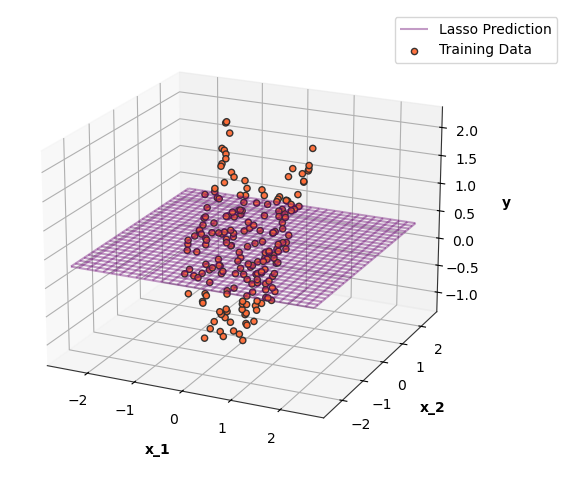

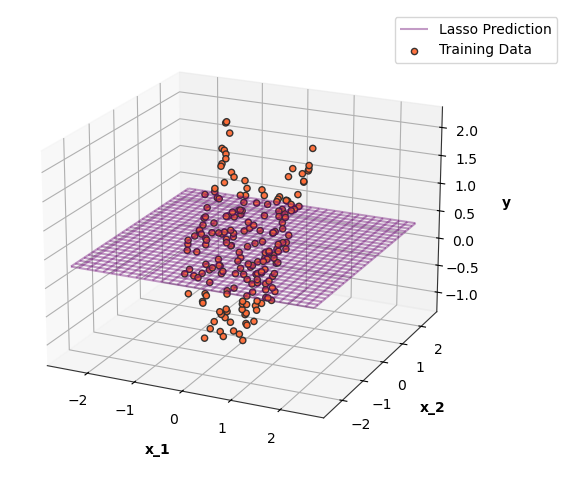

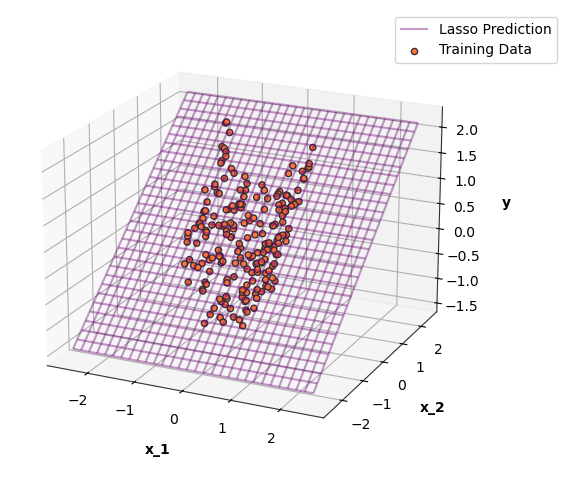

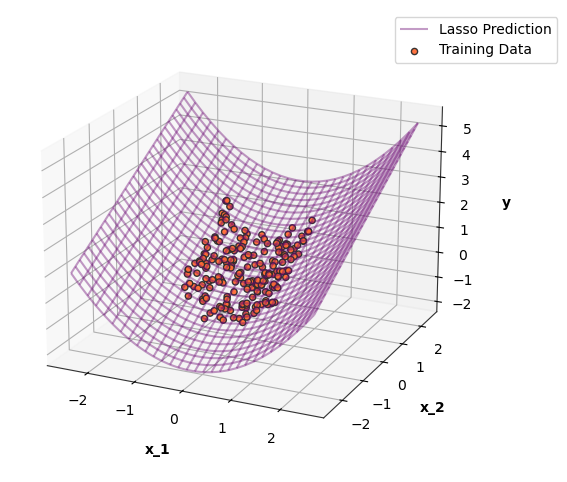

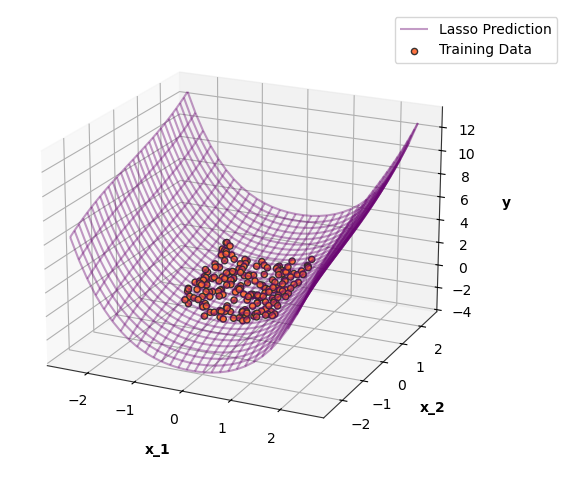

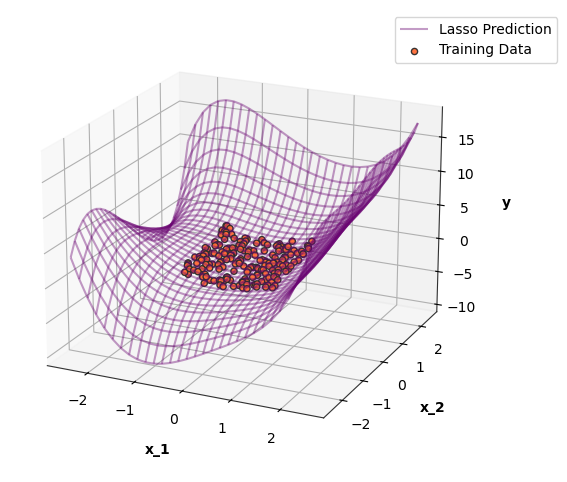

In [8]:
linear_space = np.linspace(-2.5,2.5, 30)
x1_grid, x2_grid = np.meshgrid(linear_space, linear_space)
test_grid = pf.fit_transform(np.column_stack((x1_grid.ravel(), x2_grid.ravel())))

for model in models:
    pred = model.predict(test_grid).reshape(x1_grid.shape)

    ax, _ = setup_plot(plt)
    ax.plot_wireframe(
        test_grid[:, 0].reshape(x1_grid.shape),
        test_grid[:, 1].reshape(x2_grid.shape),
        pred,
        color='#6A0572', alpha=0.4, label='Lasso Prediction'
    )
    ax.scatter(
        df['x1'], df['x2'], df['y'],
        c='#FF6B35', s=20, alpha=0.95, edgecolors='#2C2C2C', label='Training Data',
    )
    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
    plt.show()